In [3]:
import os
import random

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report, confusion_matrix

In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [5]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [6]:
print(f"x_train shape : {x_train.shape}")
print(f"y_train shape : {y_train.shape}")

print(f"x_test shape  : {x_test.shape}")
print(f"y_test shape  : {y_test.shape}")

x_train shape : (60000, 28, 28)
y_train shape : (60000,)
x_test shape  : (10000, 28, 28)
y_test shape  : (10000,)


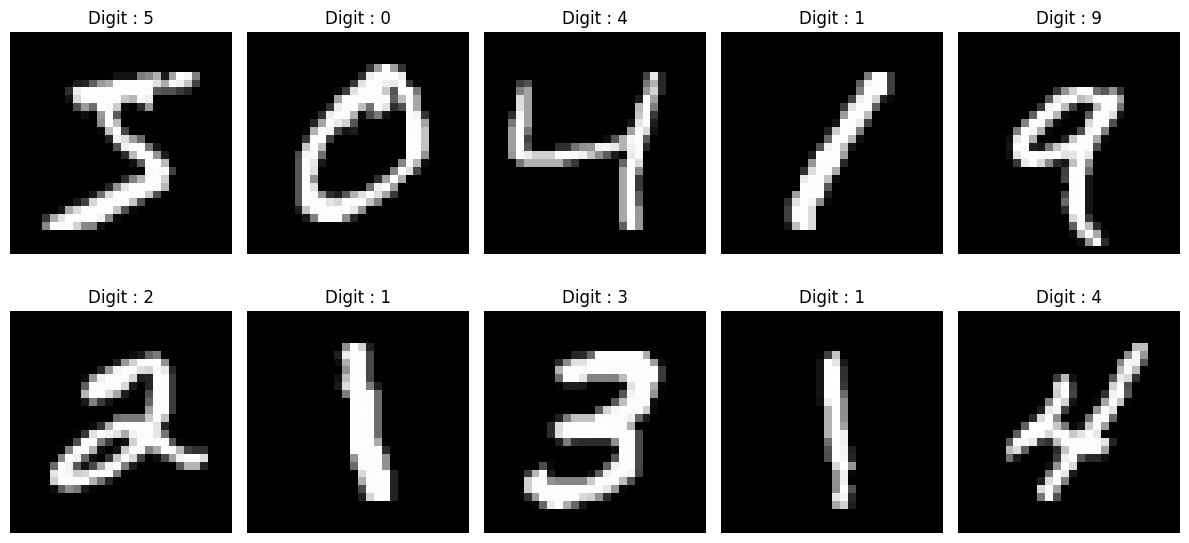

In [7]:
plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(x_train[i], cmap="gray")

    plt.title(f"Digit : {y_train[i]}")

    plt.axis("off")

plt.tight_layout()

plt.show()

In [8]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [9]:
y_train_encoded = to_categorical(y_train)

y_test_encoded = to_categorical(y_test)

In [10]:
model = Sequential([
    Input(shape=(28, 28)),

    Flatten(),

    Dense(256, activation="relu"),

    Dense(128, activation="relu"),

    Dense(64, activation="relu"),

    Dense(10, activation="softmax")
])

In [11]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    x_train,
    y_train_encoded,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    verbose=1
)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9291 - loss: 0.2360 - val_accuracy: 0.9650 - val_loss: 0.1150
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 33s 12ms/step - accuracy: 0.9714 - loss: 0.0949 - val_accuracy: 0.9720 - val_loss: 0.0994
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9798 - loss: 0.0638 - val_accuracy: 0.9703 - val_loss: 0.1078
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 18ms/step - accuracy: 0.9842 - loss: 0.0497 - val_accuracy: 0.9727 - val_loss: 0.1077
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 18ms/step - accuracy: 0.9879 - loss: 0.0379 - val_accuracy: 0.9712 - val_loss: 0.1254
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9894 - loss: 0.0335 - val_accuracy: 0.9744 - val_loss: 0.1108
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9911 - loss: 0.0266 - val_accuracy: 0.9716 - val_loss: 0.1320
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.9915 - lo

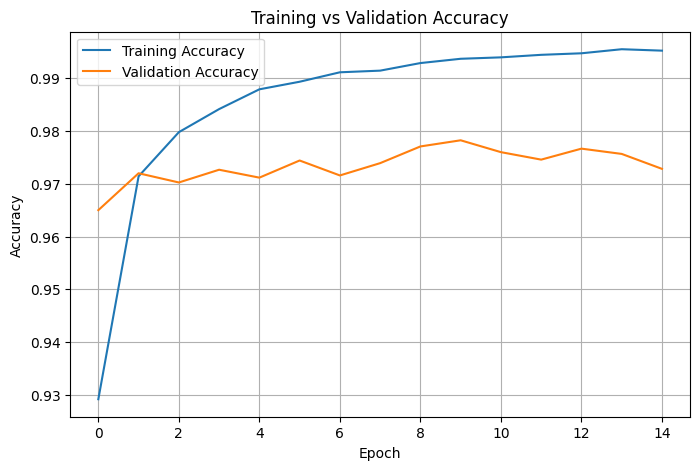

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")

plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.grid(True)

plt.show()

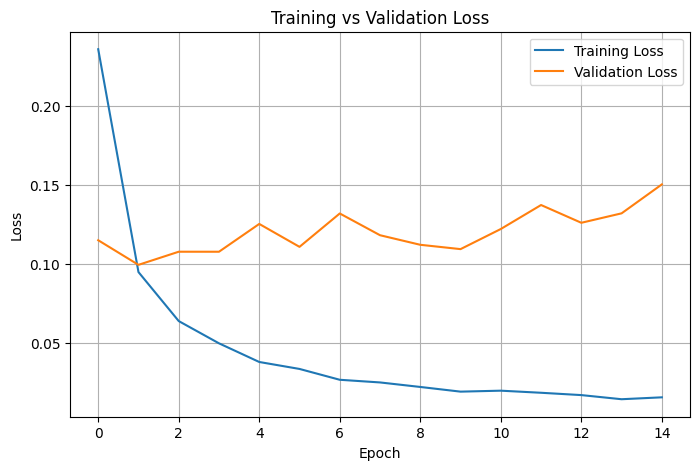

In [15]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")

plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

In [16]:
loss, accuracy = model.evaluate(
    x_test,
    y_test_encoded,
    verbose=0
)

print(f"Test Loss     : {loss:.4f}")

print(f"Test Accuracy : {accuracy:.4f}")

Test Loss     : 0.1451
Test Accuracy : 0.9723


In [17]:
predictions = model.predict(x_test)

predicted_labels = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [18]:
print(classification_report(
    y_test,
    predicted_labels
))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.98      0.98      1135
           2       0.98      0.97      0.98      1032
           3       0.96      0.98      0.97      1010
           4       0.98      0.97      0.97       982
           5       0.99      0.97      0.98       892
           6       0.98      0.98      0.98       958
           7       0.96      0.98      0.97      1028
           8       0.93      0.98      0.95       974
           9       0.99      0.92      0.95      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [19]:
cm = confusion_matrix(
    y_test,
    predicted_labels
)

print(cm)

[[ 973    1    0    0    1    0    2    0    2    1]
 [   0 1109    2    3    0    0    4    2   15    0]
 [   7    0 1000    4    2    0    2    6   11    0]
 [   2    1    4  986    0    3    0    5    6    3]
 [   4    5    2    0  953    0    6    2    2    8]
 [   2    1    0   11    1  865    3    0    8    1]
 [   6    2    0    1    4    1  942    0    2    0]
 [   2    2    6    3    0    0    1 1009    5    0]
 [   2    0    3    8    2    0    2    3  954    0]
 [   5    2    0    7   11    9    0   24   19  932]]


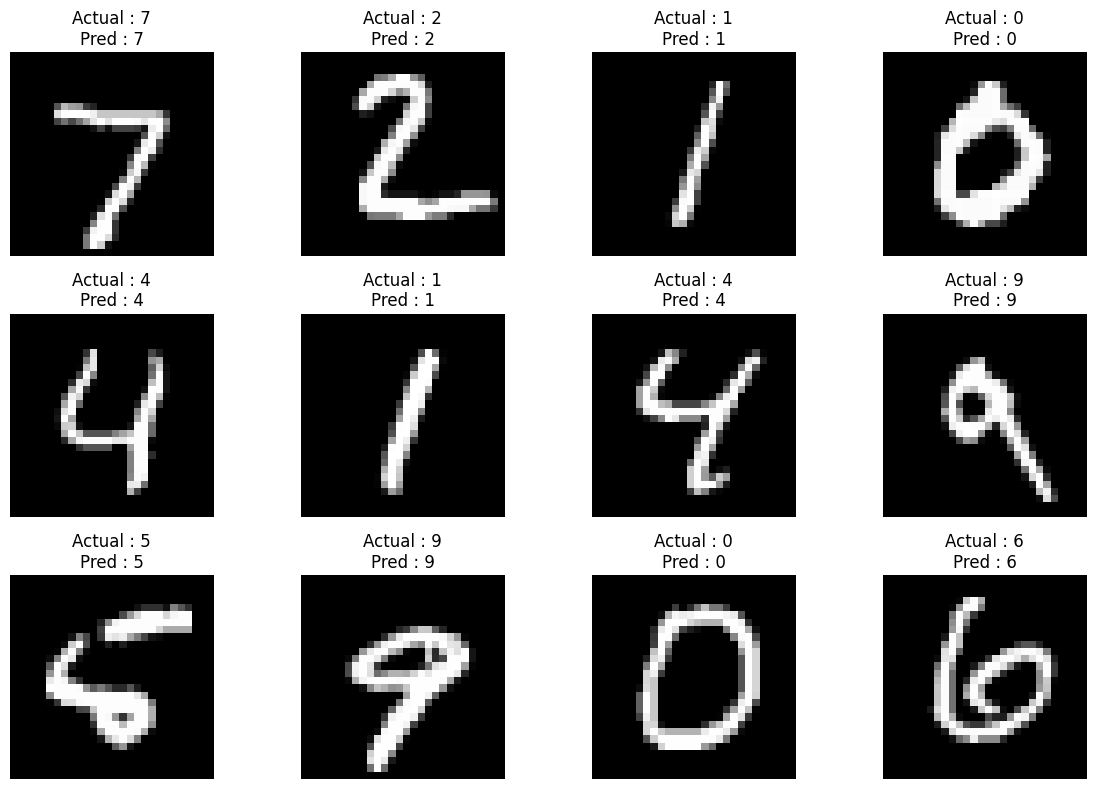

In [20]:
plt.figure(figsize=(12,8))

for i in range(12):

    plt.subplot(3,4,i+1)

    plt.imshow(x_test[i], cmap="gray")

    plt.title(
        f"Actual : {y_test[i]}\nPred : {predicted_labels[i]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [24]:
import os

MODEL_DIR = os.path.join("..", "model")
os.makedirs(MODEL_DIR, exist_ok=True)

model.save(os.path.join(MODEL_DIR, "best_model.keras"))

print("Model saved successfully!")

Model saved successfully!
